# Example 3 — Practical Applications & Benchmarking

This notebook demonstrates practical analysis workflows built on NMC simulation
outputs, and validates the results against the baseline data of
[Hokr et al.](https://doi.org/10.1364/OE.21.011757).

---

## What you will do

| Cell | Action |
|------|--------|
| **2** | Set paths and µs values to analyse |
| **3** | Discover available simulation outputs; warn about missing ones |
| **4** | Load all available photon trajectory files |
| **5** | Benchmarking — spatial and time-resolved comparison with Hokr data |
| **6** | Depth histogram — max penetration depth of top-escaped photons |
| **7** | Raman birth depth — where in the medium Raman photons are generated |
| **8** | SORS — radial Raman RD profile and max-depth vs radial offset |

---

## Sections

### 1 · Benchmarking against Hokr et al.
Spatial (radial distance) and time-resolved intensity distributions are compared
for Laser and Raman photons in both backward (reflectance) and forward
(transmittance) geometries, across available scattering coefficients.

NMC output is extracted from `photons_data_mus-*` via `exit_state` and
`prev_type`.  Hokr baseline data is read from `.dat` files if the reference
directory exists — comparison is silently skipped otherwise.

### 2 · Max penetration depth
Histogram of the deepest point reached by **top-escaped** photons (Laser and
Raman), with fitted curves:

- **Laser** — exponential fit (characterises backscattering depth scale)
- **Raman** — gamma distribution fit (physically appropriate for the depth of
  the first inelastic event along a random walk)

### 3 · Raman birth depth
Histogram of the z-coordinate at which each Raman photon first appears
(first row with `type == 2` in the trajectory), for photons that escape via
the **bottom surface** (transmitted).  Shows from what median depth transmitted
Raman signal originates.

### 4 · Spatially Offset Raman Spectroscopy (SORS)
Two quantities plotted against radial offset $r$ on a dual y-axis:

- **Left axis** — Raman radiance RD($r$): radially averaged from the 2-D
  `rd_data` map
- **Right axis** — max penetration depth $z_\text{max}(r)$: for top-escaped
  Raman photons binned by exit radial position $R = \sqrt{x^2 + y^2}$

Together these show the SORS depth-selectivity characteristic: larger radial
offset selects photons that have penetrated deeper.

---

## Output files used

| File pattern | Contents |
|---|---|
| `photons_data_mus-*_NA-*_zf-*.csv` | Full trajectories — used for all analyses |
| `rd_data_mus-*_NA-*_zf-*.csv` | 2-D radiance map — used for SORS RD profile |

---

## Requirements

At least **one** of the following simulations must have been run before
executing this notebook:

| µs (mm⁻¹) | ls (mm) | Expected file |
|-----------|---------|---------------|
| 10 | 0.1 | `photons_data_mus-10.00_NA-*_zf-*.csv` |
| 1 | 1.0 | `photons_data_mus-1.00_NA-*_zf-*.csv` |
| 0.1 | 10.0 | `photons_data_mus-0.10_NA-*_zf-*.csv` |

> **Tip:** Run examples 1 or 2 first for each µs value you want to include,
> then return here.

In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gamma
from scipy.optimize import curve_fit

NOTEBOOK_DIR = Path.cwd()
sys.path.insert(0, str(NOTEBOOK_DIR))
import nmc_utils as nmc

nmc.set_paper_style()
print("nmc_utils loaded")

nmc_utils loaded


In [5]:
# ── paths ─────────────────────────────────────────────────────────────────────
EXE_DIR  = (NOTEBOOK_DIR / "../NMC/Build/Products/Debug").resolve()

# Hokr reference data root — set to None to skip benchmarking entirely
# Each subdirectory data_01 / data_1 / data_10 must contain *_pump_b.dat etc.
HOKR_ROOT = Path(
    "/Users/vladykilya/Library/CloudStorage/"
    "OneDrive-VictoriaUniversityofWellington-STUDENT/"
    "01_Research/project_ramanNMC/data/provided/Hokr data"
)
# Override to None if you don't have the reference data:
# HOKR_ROOT = None

# ── scattering coefficients to analyse ───────────────────────────────────────
# Notebook will load whichever of these have matching output files in EXE_DIR.
MUS_VALUES = [10.0, 1.0, 0.1]          # mm⁻¹
NA         = 1.0
ZF         = 1.0

# ── depth histogram controls ──────────────────────────────────────────────────
DEPTH_BINS  = 40
DEPTH_STAT  = "density"     # "density" or "probability"
ADD_FITS    = True

# ── SORS controls ─────────────────────────────────────────────────────────────
SORS_MUS    = 10.0          # which µs to use for SORS plot
SORS_DR     = 0.05          # radial bin width (mm)

# ── figure output ─────────────────────────────────────────────────────────────
SAVE_FIGS = True
FIGS_DIR  = NOTEBOOK_DIR / "figs"
FIGS_DIR.mkdir(exist_ok=True)

print(f"EXE_DIR   : {EXE_DIR}")
print(f"HOKR_ROOT : {HOKR_ROOT}")

EXE_DIR   : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug
HOKR_ROOT : /Users/vladykilya/Library/CloudStorage/OneDrive-VictoriaUniversityofWellington-STUDENT/01_Research/project_ramanNMC/data/provided/Hokr data


In [7]:
# ── find which µs values have both photons + rd output files ──────────────────
available   = {}   # mus -> {"photons": Path, "rd": Path}
missing     = []

for mus in MUS_VALUES:
    pat_ph = f"photons_data_mus-{mus:.2f}_NA-{NA:.2f}_zf-{ZF:.2f}.csv"
    pat_rd = f"rd_data_mus-{mus:.2f}_NA-{NA:.2f}_zf-{ZF:.2f}.csv"
    found_ph = nmc.find_outputs(pat_ph, workdir=EXE_DIR)
    found_rd = nmc.find_outputs(pat_rd, workdir=EXE_DIR)
    if found_ph and found_rd:
        available[mus] = {"photons": found_ph[0], "rd": found_rd[0]}
        print(f"  ✓  µs = {mus:5.1f} mm⁻¹  (ls = {1/mus:.2f} mm)")
    else:
        missing.append(mus)
        missing_files = []
        if not found_ph: missing_files.append(pat_ph)
        if not found_rd:  missing_files.append(pat_rd)
        print(f"  ✗  µs = {mus:5.1f} mm⁻¹  — missing: {missing_files}")

if not available:
    raise RuntimeError(
        "No output files found for any µs value.\n"
        "Run the simulation (examples 1 or 2) for at least one µs value first."
    )

if missing:
   print(
        f"\nMissing outputs for µs = {missing} mm⁻¹. Those values will be skipped in all plots.",

    )

print(f"\n{len(available)} dataset(s) available: µs = {list(available.keys())} mm⁻¹")

  ✓  µs =  10.0 mm⁻¹  (ls = 0.10 mm)
  ✗  µs =   1.0 mm⁻¹  — missing: ['photons_data_mus-1.00_NA-1.00_zf-1.00.csv', 'rd_data_mus-1.00_NA-1.00_zf-1.00.csv']
  ✗  µs =   0.1 mm⁻¹  — missing: ['photons_data_mus-0.10_NA-1.00_zf-1.00.csv', 'rd_data_mus-0.10_NA-1.00_zf-1.00.csv']

Missing outputs for µs = [1.0, 0.1] mm⁻¹. Those values will be skipped in all plots.

1 dataset(s) available: µs = [10.0] mm⁻¹


In [8]:
# datasets[mus] = {"df_raw": ..., "df_summary": ..., "rd": ...}
datasets = {}

for mus, paths in available.items():
    width = 0.5    # mm — adjust if you ran with a different width
    Nx = Ny = 100  # adjust if needed

    print(f"\n--- loading µs = {mus} mm⁻¹ ---")

    df_raw, df_summary = nmc.load_photons(
        paths["photons"],
        z_bottom=width,
    )
    rd = nmc.load_rd_data(paths["rd"], Nx=Nx, Ny=Ny)

    # attach readable labels
    df_raw["type_label"]     = df_raw["type"].map(nmc.TYPE_LABELS)
    df_summary["type_label"] = df_summary["prev_type"].map(nmc.TYPE_LABELS)

    # birth depth: first row per marker where type == 2
    birth_z = (
        df_raw[df_raw["type"] == 2]
        .groupby("marker")["z"]
        .first()
        .reset_index()
        .rename(columns={"z": "z_birth"})
    )
    df_summary = df_summary.merge(birth_z, on="marker", how="left")

    datasets[mus] = {
        "df_raw":     df_raw,
        "df_summary": df_summary,
        "rd":         rd,
        "width":      width,
        "Nx":         Nx,
        "Ny":         Ny,
    }

print("\nAll datasets loaded ✓")


── loading µs = 10.0 mm⁻¹ ──────────────────────────────
[load_photons] Total rows       : 10,879,252
[load_photons] Unique markers   : 100,000
[load_photons] Summarised       : 100,000  (after type filter: [1, 2, 3])

[load_photons] Exit state counts (post-filter):
bottom      42551
top         40838
absorbed    16611

[load_photons] prev_type counts (post-filter):
1    94587
2     5413

All datasets loaded ✓


Hokr reference data found at: /Users/vladykilya/Library/CloudStorage/OneDrive-VictoriaUniversityofWellington-STUDENT/01_Research/project_ramanNMC/data/provided/Hokr data



/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/940236679.py:193: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/940236679.py:197: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.savefig(FIGS_DIR / fname, bbox_inches="tight")
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/940236679.py:193: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/940236679.py:197: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.savefig(FIGS_DIR / fname, bbox_inches="tight")
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


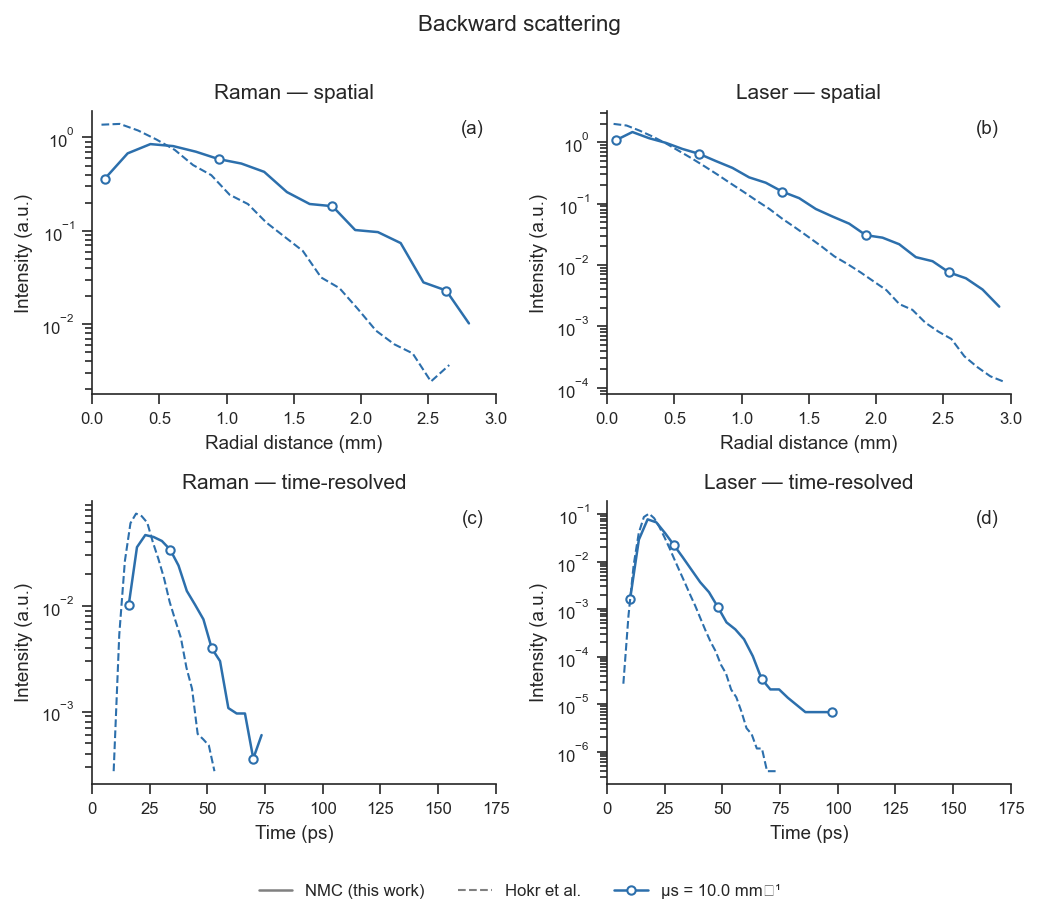

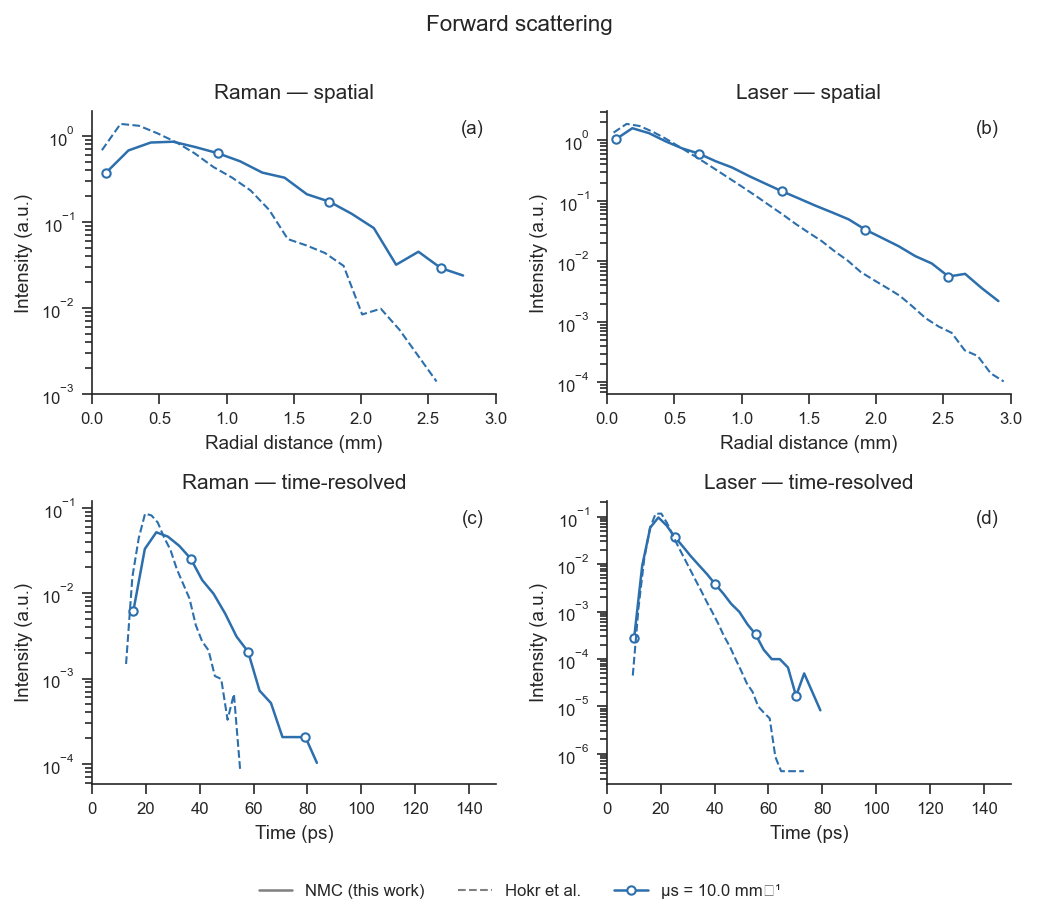

In [9]:
# ── Hokr data helpers ─────────────────────────────────────────────────────────
HOKR_DIRS = {
    10.0: "data_01",    # ls = 0.1 mm  → µs = 10
     1.0: "data_1",     # ls = 1.0 mm  → µs = 1
     0.1: "data_10",    # ls = 10  mm  → µs = 0.1
}

def _load_hokr_category(folder: Path, tag: str) -> np.ndarray | None:
    """Stack all .dat files whose name contains `tag` in `folder`."""
    files = [f for f in folder.iterdir() if f.suffix == ".dat" and tag in f.name]
    if not files:
        return None
    arrays = [np.loadtxt(f) for f in files]
    return np.vstack(arrays)

def _hist_nonzero(values: np.ndarray, bins) -> tuple:
    """Return (bin_centres, density) keeping only non-zero bins."""
    counts, edges = np.histogram(values, bins=bins, density=True)
    centres = 0.5 * (edges[:-1] + edges[1:])
    mask = counts > 0
    return centres[mask], counts[mask]

# ── colour / marker scheme — one per µs ───────────────────────────────────────
MUS_STYLE = {
    10.0: dict(color="#2C6FAC", marker="o"),
     1.0: dict(color="#E8602C", marker="^"),
     0.1: dict(color="#3DAA62", marker="s"),
}
BINS_N = "doane"

# ── check Hokr availability ───────────────────────────────────────────────────
hokr_available = (
    HOKR_ROOT is not None
    and Path(HOKR_ROOT).exists()
)
if not hokr_available:
    print("Hokr reference data not found — plotting NMC results only.\n")
else:
    print(f"Hokr reference data found at: {HOKR_ROOT}\n")

# ── figure setup: backward + forward, each 2×2 ───────────────────────────────
panel_labels = [["(a)", "(b)"], ["(c)", "(d)"]]
row_titles   = [["Raman",       "Laser"],
                ["Raman (time)","Laser (time)"]]

fig_b, axs_b = plt.subplots(2, 2, figsize=(7.0, 5.6))
fig_f, axs_f = plt.subplots(2, 2, figsize=(7.0, 5.6))

for mus in available:
    ds   = datasets[mus]
    summ = ds["df_summary"]
    st   = MUS_STYLE[mus]
    ls_label = f"µs = {mus} mm⁻¹ (ls = {1/mus:.2f} mm)"

    # ── extract four NMC subsets ───────────────────────────────────────────
    sel = summ[summ["term_mode"] == "term"].copy()

    laser_b = sel[(sel["prev_type"] == 1) & (sel["exit_state"] == "top")]
    laser_f = sel[(sel["prev_type"] == 1) & (sel["exit_state"] == "bottom")]
    raman_b = sel[(sel["prev_type"] == 2) & (sel["exit_state"] == "top")]
    raman_f = sel[(sel["prev_type"] == 2) & (sel["exit_state"] == "bottom")]

    # exit (x, y) for NMC photons come from df_raw termination rows
    df_raw = ds["df_raw"]
    term_rows = df_raw[df_raw["type"] == 0].groupby("marker").last().reset_index()

    def _nmc_r(subset: pd.DataFrame) -> np.ndarray:
        merged = subset[["marker"]].merge(term_rows[["marker","x","y"]], on="marker")
        return np.sqrt(merged["x"]**2 + merged["y"]**2).values

    def _nmc_t(subset: pd.DataFrame) -> np.ndarray:
        merged = subset[["marker"]].merge(term_rows[["marker","t"]], on="marker")
        return merged["t"].values

    # ── spatial plots ──────────────────────────────────────────────────────
    for (ax, vals, label) in [
        (axs_b[0,0], _nmc_r(raman_b), "Raman backward"),
        (axs_b[0,1], _nmc_r(laser_b), "Laser backward"),
        (axs_f[0,0], _nmc_r(raman_f), "Raman forward"),
        (axs_f[0,1], _nmc_r(laser_f), "Laser forward"),
    ]:
        if len(vals) == 0:
            continue
        cx, cy = _hist_nonzero(vals, BINS_N)
        ax.plot(cx, cy,
                color=st["color"], marker=st["marker"],
                linestyle="-", markevery=5, linewidth=1.2,
                markersize=4, markerfacecolor="white",
                markeredgewidth=1.0,
                label=ls_label)
        ax.set_yscale("log")
        ax.set_xlim(left=0, right=3)
        ax.set_xlabel("Radial distance (mm)")
        ax.set_ylabel("Intensity (a.u.)")

    # ── time-resolved plots ────────────────────────────────────────────────
    for (ax, vals, label) in [
        (axs_b[1,0], _nmc_t(raman_b), "Raman backward"),
        (axs_b[1,1], _nmc_t(laser_b), "Laser backward"),
        (axs_f[1,0], _nmc_t(raman_f), "Raman forward"),
        (axs_f[1,1], _nmc_t(laser_f), "Laser forward"),
    ]:
        if len(vals) == 0:
            continue
        cx, cy = _hist_nonzero(vals, BINS_N)
        ax.plot(cx, cy,
                color=st["color"], marker=st["marker"],
                linestyle="-", markevery=5, linewidth=1.2,
                markersize=4, markerfacecolor="white",
                markeredgewidth=1.0,
                label=ls_label)
        ax.set_yscale("log")
        ax.set_xlim(left=0, right=175)
        ax.set_xlabel("Time (ps)")
        ax.set_ylabel("Intensity (a.u.)")

    # ── Hokr overlay ───────────────────────────────────────────────────────
    if hokr_available and mus in HOKR_DIRS:
        hokr_folder = Path(HOKR_ROOT) / HOKR_DIRS[mus]
        if not hokr_folder.exists():
            print(f"  [warn] Hokr folder not found: {hokr_folder}")
        else:
            h_rb = _load_hokr_category(hokr_folder, "raman_b")
            h_rf = _load_hokr_category(hokr_folder, "raman_f")
            h_lb = _load_hokr_category(hokr_folder, "pump_b")
            h_lf = _load_hokr_category(hokr_folder, "pump_f")

            for (ax, arr, xlim) in [
                (axs_b[0,0], h_rb, 3),
                (axs_b[0,1], h_lb, 3),
                (axs_f[0,0], h_rf, 3),
                (axs_f[0,1], h_lf, 3),
            ]:
                if arr is None: continue
                r = np.sqrt(arr[:,0]**2 + arr[:,1]**2)
                cx, cy = _hist_nonzero(r, BINS_N)
                ax.plot(cx, cy,
                        color=st["color"], linestyle="--",
                        linewidth=1.0, label=f"Hokr {ls_label}")
                ax.set_xlim(left=0, right=xlim)

            for (ax, arr, xlim) in [
                (axs_b[1,0], h_rb, 175),
                (axs_b[1,1], h_lb, 175),
                (axs_f[1,0], h_rf, 150),
                (axs_f[1,1], h_lf, 150),
            ]:
                if arr is None: continue
                t = arr[:,5]
                cx, cy = _hist_nonzero(t, BINS_N)
                ax.plot(cx, cy,
                        color=st["color"], linestyle="--",
                        linewidth=1.0, label=f"Hokr {ls_label}")
                ax.set_xlim(left=0, right=xlim)

# ── panel labels & titles ─────────────────────────────────────────────────────
for fig, axs, direction in [(fig_b, axs_b, "Backward"), (fig_f, axs_f, "Forward")]:
    subplot_titles = [
        ["Raman — spatial",       "Laser — spatial"],
        ["Raman — time-resolved", "Laser — time-resolved"],
    ]
    for r in range(2):
        for c in range(2):
            axs[r,c].text(
                0.97, 0.97, panel_labels[r][c],
                transform=axs[r,c].transAxes,
                va="top", ha="right", fontsize=9,
            )
            axs[r,c].set_title(subplot_titles[r][c])
            sns.despine(ax=axs[r,c])

    # shared legend
    legend_elements = [
        Line2D([0],[0], color="grey", ls="-",  lw=1.2, label="NMC (this work)"),
        Line2D([0],[0], color="grey", ls="--", lw=1.0, label="Hokr et al."),
    ] + [
        Line2D([0],[0],
               color=MUS_STYLE[m]["color"],
               marker=MUS_STYLE[m]["marker"],
               lw=1.2, markersize=4,
               markerfacecolor="white",
               label=f"µs = {m} mm⁻¹")
        for m in available
    ]
    fig.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.06),
        ncol=3,
        frameon=False,
    )
    fig.suptitle(f"{direction} scattering", y=1.01)
    fig.tight_layout()

    if SAVE_FIGS:
        fname = f"ex3_benchmark_{'backward' if direction == 'Backward' else 'forward'}.pdf"
        fig.savefig(FIGS_DIR / fname, bbox_inches="tight")

plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/2119878489.py:135: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.tight_layout()
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/2119878489.py:135: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/2119878489.py:138: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.savefig(FIGS_DIR / "ex3_depth_histogram.pdf", bbox_inches="tight")
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.canvas.print_

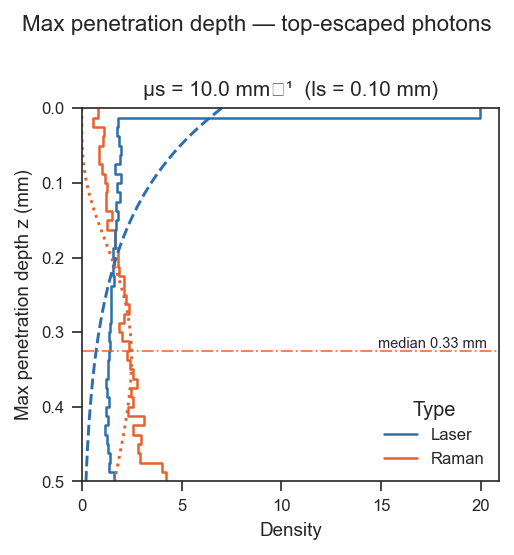

In [10]:
# one subplot per available µs value
n_panels = len(available)
fig, axes = plt.subplots(1, n_panels, figsize=(3.5 * n_panels, 3.6), sharey=True)
if n_panels == 1:
    axes = [axes]

for ax, mus in zip(axes, available):
    ds    = datasets[mus]
    summ  = ds["df_summary"]
    width = ds["width"]

    sel = summ[
        (summ["exit_state"]  == "top") &
        (summ["prev_type"].isin([1, 2])) &
        (summ["term_mode"]   == "term")
    ].copy()
    sel["Type"] = sel["prev_type"].map(nmc.TYPE_LABELS)

    bin_edges   = np.linspace(0.0, width, DEPTH_BINS + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    palette = {
        nmc.TYPE_LABELS[1]: nmc.TYPE_COLORS[1],
        nmc.TYPE_LABELS[2]: nmc.TYPE_COLORS[2],
    }

    sns.histplot(
        data=sel,
        y="max_z",
        hue="Type",
        bins=bin_edges,
        stat=DEPTH_STAT,
        common_norm=False,
        element="step",
        fill=False,
        linewidth=1.2,
        palette=palette,
        ax=ax,
        legend=(ax == axes[0]),
    )

    # all spines visible (closed box)
    for spine in ax.spines.values():
        spine.set_visible(True)

    ax.set_ylim(0.0, width)
    ax.invert_yaxis()   # z = 0 at top
    ax.set_ylabel("Max penetration depth z (mm)" if ax == axes[0] else "")
    ax.set_xlabel(DEPTH_STAT.capitalize())
    ax.set_title(f"µs = {mus} mm⁻¹  (ls = {1/mus:.2f} mm)")
    ax.grid(False)

    # ── fitting curves ────────────────────────────────────────────────────
    if ADD_FITS:
        z_grid = np.linspace(0.0, width, 400)

        # Laser — exponential fit on binned data
        laser_z = sel.loc[sel["Type"] == nmc.TYPE_LABELS[1], "max_z"].to_numpy()
        if len(laser_z) > 10:
            counts_l, _ = np.histogram(laser_z, bins=bin_edges, density=True)
            mask_l = counts_l > 0

            def _exp_pdf(z, lam):
                return lam * np.exp(-lam * z)

            try:
                p0_l = [1.0 / (laser_z.mean() + 1e-9)]
                popt_l, _ = curve_fit(
                    _exp_pdf,
                    bin_centers[mask_l],
                    counts_l[mask_l],
                    p0=p0_l,
                    bounds=(0, np.inf),
                    maxfev=4000,
                )
                lam_fit = float(popt_l[0])
                ax.plot(
                    _exp_pdf(z_grid, lam_fit), z_grid,
                    linestyle="--", linewidth=1.4,
                    color=nmc.TYPE_COLORS[1],
                    label=f"Laser fit (exp, λ={lam_fit:.2f})",
                )
            except RuntimeError:
                warnings.warn(f"Laser exponential fit failed for µs={mus}.")

        # Raman — gamma distribution fit
        raman_z = sel.loc[sel["Type"] == nmc.TYPE_LABELS[2], "max_z"].to_numpy()
        if len(raman_z) > 10:
            counts_r, _ = np.histogram(raman_z, bins=bin_edges, density=True)
            mask_r = counts_r > 0

            def _gamma_pdf(z, a, scale):
                return gamma.pdf(z, a=a, scale=scale)

            try:
                # moment-matching starting guess
                mu_r  = raman_z.mean()
                var_r = raman_z.var() + 1e-9
                p0_r  = [mu_r**2 / var_r, var_r / mu_r]
                popt_r, _ = curve_fit(
                    _gamma_pdf,
                    bin_centers[mask_r],
                    counts_r[mask_r],
                    p0=p0_r,
                    bounds=([0, 0], [np.inf, np.inf]),
                    maxfev=4000,
                )
                a_fit, sc_fit = float(popt_r[0]), float(popt_r[1])
                ax.plot(
                    _gamma_pdf(z_grid, a_fit, sc_fit), z_grid,
                    linestyle=":", linewidth=1.4,
                    color=nmc.TYPE_COLORS[2],
                    label=f"Raman fit (Γ, α={a_fit:.2f})",
                )
            except RuntimeError:
                warnings.warn(f"Raman gamma fit failed for µs={mus}.")

            # median line
            med = float(np.median(raman_z))
            ax.axhline(med, linestyle="-.", linewidth=0.9,
                       color=nmc.TYPE_COLORS[2], alpha=0.8)
            ax.text(
                0.97, med, f"median {med:.2f} mm",
                ha="right", va="bottom",
                transform=ax.get_yaxis_transform(),
                fontsize=7,
            )

    if ax == axes[0]:
        legend = ax.get_legend()
        if legend:
            legend.set_frame_on(False)

fig.suptitle("Max penetration depth — top-escaped photons", y=1.01)
fig.tight_layout()

if SAVE_FIGS:
    fig.savefig(FIGS_DIR / "ex3_depth_histogram.pdf", bbox_inches="tight")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/1664633867.py:60: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.tight_layout()
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/1664633867.py:60: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/1664633867.py:63: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.savefig(FIGS_DIR / "ex3_raman_birth_depth.pdf", bbox_inches="tight")
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.canvas.print_f

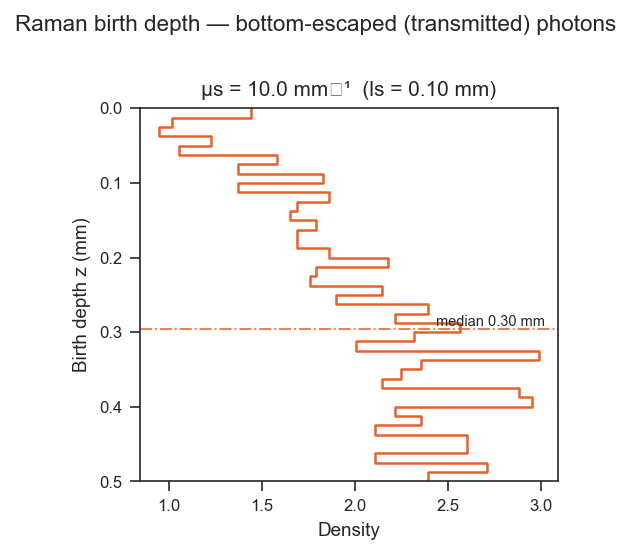

In [11]:
n_panels = len(available)
fig, axes = plt.subplots(1, n_panels, figsize=(3.5 * n_panels, 3.6), sharey=True)
if n_panels == 1:
    axes = [axes]

for ax, mus in zip(axes, available):
    ds    = datasets[mus]
    summ  = ds["df_summary"]
    width = ds["width"]

    # bottom-escaped Raman photons only — one row per marker
    sel = summ[
        (summ["exit_state"] == "bottom") &
        (summ["prev_type"]  == 2) &
        (summ["term_mode"]  == "term") &
        (summ["z_birth"].notna())
    ].copy()

    if sel.empty:
        ax.set_title(f"µs = {mus} mm⁻¹\n(no data)")
        continue

    bin_edges = np.linspace(0.0, width, DEPTH_BINS + 1)

    sns.histplot(
        data=sel,
        y="z_birth",
        bins=bin_edges,
        stat=DEPTH_STAT,
        element="step",
        fill=False,
        linewidth=1.2,
        color=nmc.TYPE_COLORS[2],
        ax=ax,
        label="Raman",
    )

    for spine in ax.spines.values():
        spine.set_visible(True)

    ax.set_ylim(0.0, width)
    ax.invert_yaxis()
    ax.set_ylabel("Birth depth z (mm)" if ax == axes[0] else "")
    ax.set_xlabel(DEPTH_STAT.capitalize())
    ax.set_title(f"µs = {mus} mm⁻¹  (ls = {1/mus:.2f} mm)")
    ax.grid(False)

    # median annotation
    med = float(sel["z_birth"].median())
    ax.axhline(med, linestyle="-.", linewidth=0.9,
               color=nmc.TYPE_COLORS[2], alpha=0.85)
    ax.text(
        0.97, med, f"median {med:.2f} mm",
        ha="right", va="bottom",
        transform=ax.get_yaxis_transform(),
        fontsize=7,
    )

fig.suptitle("Raman birth depth — bottom-escaped (transmitted) photons", y=1.01)
fig.tight_layout()

if SAVE_FIGS:
    fig.savefig(FIGS_DIR / "ex3_raman_birth_depth.pdf", bbox_inches="tight")
plt.show()

/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/1951350026.py:104: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.tight_layout()
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/1951350026.py:104: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_310/1951350026.py:107: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.savefig(FIGS_DIR / "ex3_sors.pdf", bbox_inches="tight")
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


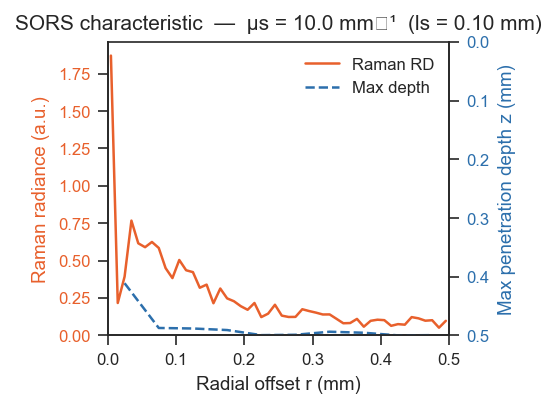

In [12]:
if SORS_MUS not in available:
    raise RuntimeError(
        f"SORS_MUS = {SORS_MUS} mm⁻¹ is not in the available datasets.\n"
        f"Available: {list(available.keys())} mm⁻¹"
    )

ds    = datasets[SORS_MUS]
summ  = ds["df_summary"]
rd    = ds["rd"]
width = ds["width"]
Nx    = ds["Nx"]
Ny    = ds["Ny"]
df_raw = ds["df_raw"]

# ── 1. Raman RD radial profile from rd_data 2-D array ───────────────���─────
x_arr, y_arr = nmc.build_xy_coords(Nx, Ny, width)
dx = x_arr[1] - x_arr[0]

def _radial_profile(arr: np.ndarray) -> tuple:
    ix  = np.arange(Nx)
    iy  = np.arange(Ny)
    IY, IX = np.meshgrid(iy, ix)
    R_pix = np.sqrt((IX - Nx/2)**2 + (IY - Ny/2)**2)
    r_max = int(np.floor(min(Nx, Ny) / 2))
    profile = np.zeros(r_max)
    for ri in range(r_max):
        mask = (R_pix >= ri) & (R_pix < ri + 1)
        profile[ri] = arr[mask].mean() if mask.any() else 0.0
    r_mm = (np.arange(r_max) + 0.5) * dx
    return r_mm, profile

r_rd, raman_rd_profile = _radial_profile(rd["raman"])

# ── 2. max_z(r) — top-escaped Raman photons, binned by exit R ────────────
# get exit (x, y) from termination rows in df_raw
term_rows = (
    df_raw[df_raw["type"] == 0]
    .groupby("marker")[["x","y"]]
    .last()
    .reset_index()
)

raman_top = summ[
    (summ["prev_type"]  == 2) &
    (summ["exit_state"] == "top") &
    (summ["term_mode"]  == "term")
][["marker","max_z"]].merge(term_rows, on="marker")

raman_top["R_exit"] = np.sqrt(raman_top["x"]**2 + raman_top["y"]**2)

# radial bins
r_max_sors = width               # mm
r_bins     = np.arange(0.0, r_max_sors + SORS_DR, SORS_DR)
r_centers  = 0.5 * (r_bins[:-1] + r_bins[1:])

max_z_r = np.full(len(r_centers), np.nan)
for i, (r_lo, r_hi) in enumerate(zip(r_bins[:-1], r_bins[1:])):
    mask = (raman_top["R_exit"] >= r_lo) & (raman_top["R_exit"] < r_hi)
    vals = raman_top.loc[mask, "max_z"].values
    if len(vals) > 0:
        max_z_r[i] = float(np.max(vals))

# ── 3. dual-axis plot ──────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(3.5, 2.8))
ax2 = ax1.twinx()

# left axis — Raman RD profile
l1, = ax1.plot(
    r_rd, raman_rd_profile,
    color=nmc.TYPE_COLORS[2], linewidth=1.2,
    label="Raman RD",
)
ax1.set_xlabel("Radial offset r (mm)")
ax1.set_ylabel("Raman radiance (a.u.)", color=nmc.TYPE_COLORS[2])
ax1.tick_params(axis="y", labelcolor=nmc.TYPE_COLORS[2])
ax1.set_xlim(0, r_max_sors)
ax1.set_ylim(bottom=0)

# right axis — max_z(r), inverted so deeper = lower
valid = ~np.isnan(max_z_r)
l2, = ax2.plot(
    r_centers[valid], max_z_r[valid],
    color=nmc.TYPE_COLORS[1], linewidth=1.2,
    linestyle="--",
    label="Max depth",
)
ax2.set_ylabel("Max penetration depth z (mm)", color=nmc.TYPE_COLORS[1])
ax2.tick_params(axis="y", labelcolor=nmc.TYPE_COLORS[1])
ax2.set_ylim(0, width)
ax2.invert_yaxis()   # deeper = lower on plot

# combined legend
ax1.legend(
    handles=[l1, l2],
    labels=["Raman RD", "Max depth"],
    frameon=False,
    loc="upper right",
)

ax1.set_title(
    f"SORS characteristic  —  µs = {SORS_MUS} mm⁻¹  (ls = {1/SORS_MUS:.2f} mm)"
)
sns.despine(ax=ax1, right=False)   # keep right spine for twin axis
fig.tight_layout()

if SAVE_FIGS:
    fig.savefig(FIGS_DIR / "ex3_sors.pdf", bbox_inches="tight")
plt.show()